In [3]:
# -*- coding: utf-8 -*-
import numpy as np
import math

# Create random input and output data
x = np.linspace(-math.pi, math.pi, 2000)
y = np.sin(x)

# Randomly initialize weights
a = np.random.randn()
b = np.random.randn()
c = np.random.randn()
d = np.random.randn()
e = np.random.randn()
f = np.random.randn()
g = np.random.randn()
h = np.random.randn()

learning_rate = 1e-10
for t in range(10000):
    # Forward pass: compute predicted y
    # y = a + b x + c x^2 + d x^3 + e x^4 + f x^5 + g x^6 + h x^7
    y_pred = a + b * x + c * x ** 2 + d * x ** 3 + e * x ** 4 + f * x ** 5 + g * x ** 6 + h * x ** 7

    # Compute and print loss
    loss = np.square(y_pred - y).sum()
    if t % 100 == 99:
        print(t, loss)

    # Backprop to compute gradients of a, b, c, d, e, f, g, h with respect to loss
    grad_y_pred = 2.0 * (y_pred - y)
    grad_a = grad_y_pred.sum()
    grad_b = (grad_y_pred * x).sum()
    grad_c = (grad_y_pred * x ** 2).sum()
    grad_d = (grad_y_pred * x ** 3).sum()
    grad_e = (grad_y_pred * x ** 4).sum()
    grad_f = (grad_y_pred * x ** 5).sum()
    grad_g = (grad_y_pred * x ** 6).sum()
    grad_h = (grad_y_pred * x ** 7).sum()

    # Update weights
    a -= learning_rate * grad_a
    b -= learning_rate * grad_b
    c -= learning_rate * grad_c
    d -= learning_rate * grad_d
    e -= learning_rate * grad_e
    f -= learning_rate * grad_f
    g -= learning_rate * grad_g
    h -= learning_rate * grad_h

print(f'Result: y = {a} + {b} x + {c} x^2 + {d} x^3 + {e} x^4 + {f} x^5 + {g} x^6 + {h} x^7')

99 192460.88671087855
199 143547.39554942213
299 141449.296468406
399 139513.01356497756
499 137609.04696785918
599 135736.4924072404
699 133894.81046470228
799 132083.4719984509
899 130301.95700313692
999 128549.7544492854
1099 126826.3621281583
1199 125131.28649930228
1299 123464.04254073508
1399 121824.15360171982
1499 120211.15125808485
1599 118624.5751700454
1699 117063.9729424827
1799 115528.89998763753
1899 114018.91939017914
1999 112533.60177460528
2099 111072.52517493555
2199 109635.27490665608
2299 108221.44344087924
2399 106830.63028067807
2499 105462.44183955892
2599 104116.49132203354
2699 102792.39860625817
2799 101489.79012869959
2899 100208.29877079497
2999 98947.5637475728
3099 97707.23049819622
3199 96486.95057840113
3299 95286.38155479298
3399 94105.1869009703
3499 92943.03589544445
3599 91799.60352132336
3699 90674.57036773117
3799 89567.62253292873
3899 88478.45152911302
3999 87406.75418885835
4099 86352.23257317778
4199 85314.59388117174
4299 84293.55036124114
439

1c

In [4]:
# -*- coding: utf-8 -*-
import torch
import math

dtype = torch.float
device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")
print(f"Using {device} device")

# Create random input and output data
x = torch.linspace(-math.pi, math.pi, 2000, device=device, dtype=dtype)
y = torch.sin(x)

# Prepare the input tensor (x, x^2, ..., x^7)
p = torch.tensor([1, 2, 3, 4, 5, 6, 7], device=device)
xx = x.unsqueeze(-1).pow(p)

# Use the nn package to define our model and loss function
model = torch.nn.Sequential(
    torch.nn.Linear(7, 1),
    torch.nn.Flatten(0, 1)
).to(device)

loss_fn = torch.nn.MSELoss(reduction='sum')

# Use the best result idea from 1(b): very small learning rate
learning_rate = 1e-10
optimizer = torch.optim.SGD(model.parameters(), lr=learning_rate)

for t in range(10000):
    # Forward pass: compute predicted y by passing x to the model
    y_pred = model(xx)

    # Compute and print loss
    loss = loss_fn(y_pred, y)
    if t % 100 == 99:
        print(t, loss.item())

    # Zero gradients, backward pass, and update
    optimizer.zero_grad()
    loss.backward()
    optimizer.step()

linear_layer = model[0]
print(
    f"Result: y = {linear_layer.bias.item()} + "
    f"{linear_layer.weight[0,0].item()} x + "
    f"{linear_layer.weight[0,1].item()} x^2 + "
    f"{linear_layer.weight[0,2].item()} x^3 + "
    f"{linear_layer.weight[0,3].item()} x^4 + "
    f"{linear_layer.weight[0,4].item()} x^5 + "
    f"{linear_layer.weight[0,5].item()} x^6 + "
    f"{linear_layer.weight[0,6].item()} x^7"
)

ModuleNotFoundError: No module named 'torch'

1d

In [ ]:
# -*- coding: utf-8 -*-
import torch
import math

dtype = torch.float
device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")
print(f"Using {device} device")

# Create data
x = torch.linspace(-math.pi, math.pi, 2000, device=device, dtype=dtype)
y = torch.sin(x)

# Shuffle and split into training and validation sets
perm = torch.randperm(x.shape[0], device=device)
x = x[perm]
y = y[perm]

split_idx = int(0.8 * x.shape[0])
x_train, x_val = x[:split_idx], x[split_idx:]
y_train, y_val = y[:split_idx], y[split_idx:]

def make_features(x, degree):
    powers = torch.arange(1, degree + 1, device=device, dtype=torch.long)
    return x.unsqueeze(-1).pow(powers)

def mse(y_pred, y_true):
    return ((y_pred - y_true) ** 2).mean().item()

results = []

for degree in range(1, 8):
    # Build polynomial features
    xx_train = make_features(x_train, degree)
    xx_val = make_features(x_val, degree)

    # Linear model for polynomial regression
    model = torch.nn.Sequential(
        torch.nn.Linear(degree, 1),
        torch.nn.Flatten(0, 1)
    ).to(device)

    loss_fn = torch.nn.MSELoss(reduction='mean')
    optimizer = torch.optim.SGD(model.parameters(), lr=1e-6)

    # Train model
    for t in range(5000):
        y_pred = model(xx_train)
        loss = loss_fn(y_pred, y_train)

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

    # Compute training and validation MSE
    with torch.no_grad():
        train_pred = model(xx_train)
        val_pred = model(xx_val)

        train_mse = mse(train_pred, y_train)
        val_mse = mse(val_pred, y_val)

    results.append((degree, train_mse, val_mse))
    print(f"Degree {degree}: Train MSE = {train_mse:.6f}, Validation MSE = {val_mse:.6f}")

# Find best degree based on validation MSE
best_degree, best_train_mse, best_val_mse = min(results, key=lambda x: x[2])

print("\nBest model based on validation MSE:")
print(f"Degree {best_degree}: Train MSE = {best_train_mse:.6f}, Validation MSE = {best_val_mse:.6f}")

1e

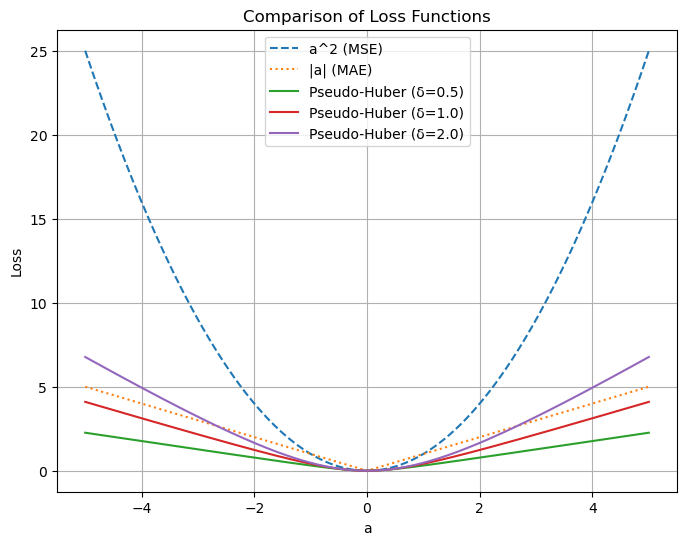

In [5]:
import numpy as np
import matplotlib.pyplot as plt
import os

# Create plots folder if it doesn't exist
os.makedirs("plots", exist_ok=True)

# Define range of a values
a = np.linspace(-5, 5, 500)

# Define different delta values
deltas = [0.5, 1.0, 2.0]

# Define loss functions
def pseudo_huber(a, delta):
    return delta**2 * (np.sqrt(1 + (a/delta)**2) - 1)

# Plot
plt.figure(figsize=(8,6))

# Plot a^2
plt.plot(a, a**2, label="a^2 (MSE)", linestyle="--")

# Plot |a|
plt.plot(a, np.abs(a), label="|a| (MAE)", linestyle=":")

# Plot pseudo-Huber for different deltas
for delta in deltas:
    plt.plot(a, pseudo_huber(a, delta), label=f"Pseudo-Huber (δ={delta})")

plt.title("Comparison of Loss Functions")
plt.xlabel("a")
plt.ylabel("Loss")
plt.legend()
plt.grid()

# Save the plot
plt.savefig("plots/pseudo_huber_plot.png", dpi=300, bbox_inches='tight')

plt.show()

1f

In [ ]:
# -*- coding: utf-8 -*-
import torch
import math

# We want to be able to train our model on an accelerator
# such as CUDA, MPS, MTIA, or XPU. If the current accelerator is available,
# we will use it. Otherwise, we use the CPU.

dtype = torch.float
device = torch.accelerator.current_accelerator().type if torch.accelerator.is_available() else "cpu"
print(f"Using {device} device")
torch.set_default_device(device)

# Create Tensors to hold input and outputs.
# By default, requires_grad=False, which indicates that we do not need to
# compute gradients with respect to these Tensors during the backward pass.
x = torch.linspace(-math.pi, math.pi, 2000, dtype=dtype)
y = torch.sin(x)

# Create random Tensors for weights. For a seventh order polynomial, we need
# 8 weights: y = a + b x + c x^2 + d x^3 + e x^4 + f x^5 + g x^6 + h x^7
# Setting requires_grad=True indicates that we want to compute gradients with
# respect to these Tensors during the backward pass.
a = torch.randn((), dtype=dtype, requires_grad=True)
b = torch.randn((), dtype=dtype, requires_grad=True)
c = torch.randn((), dtype=dtype, requires_grad=True)
d = torch.randn((), dtype=dtype, requires_grad=True)
e = torch.randn((), dtype=dtype, requires_grad=True)
f = torch.randn((), dtype=dtype, requires_grad=True)
g = torch.randn((), dtype=dtype, requires_grad=True)
h = torch.randn((), dtype=dtype, requires_grad=True)

# Custom Pseudo-Huber loss
def pseudo_huber_loss(y_pred, y_true, delta=1.0):
    z = y_pred - y_true
    return (delta**2 * (torch.sqrt(1 + (z / delta) ** 2) - 1)).sum()

delta = 1.0
learning_rate = 1e-6
for t in range(2000):
    # Forward pass: compute predicted y using operations on Tensors.
    y_pred = (
        a
        + b * x
        + c * x ** 2
        + d * x ** 3
        + e * x ** 4
        + f * x ** 5
        + g * x ** 6
        + h * x ** 7
    )

    # Compute and print loss using the custom Pseudo-Huber loss.
    loss = pseudo_huber_loss(y_pred, y, delta=delta)
    if t % 100 == 99:
        print(t, loss.item())

    # Use autograd to compute the backward pass. This call will compute the
    # gradient of loss with respect to all Tensors with requires_grad=True.
    loss.backward()

    # Manually update weights using gradient descent. Wrap in torch.no_grad()
    # because weights have requires_grad=True, but we don't need to track this
    # in autograd.
    with torch.no_grad():
        a -= learning_rate * a.grad
        b -= learning_rate * b.grad
        c -= learning_rate * c.grad
        d -= learning_rate * d.grad
        e -= learning_rate * e.grad
        f -= learning_rate * f.grad
        g -= learning_rate * g.grad
        h -= learning_rate * h.grad

        # Manually zero the gradients after updating weights
        a.grad = None
        b.grad = None
        c.grad = None
        d.grad = None
        e.grad = None
        f.grad = None
        g.grad = None
        h.grad = None

print(
    f"Result: y = {a.item()} + {b.item()} x + {c.item()} x^2 + {d.item()} x^3 + "
    f"{e.item()} x^4 + {f.item()} x^5 + {g.item()} x^6 + {h.item()} x^7"
)

2ci

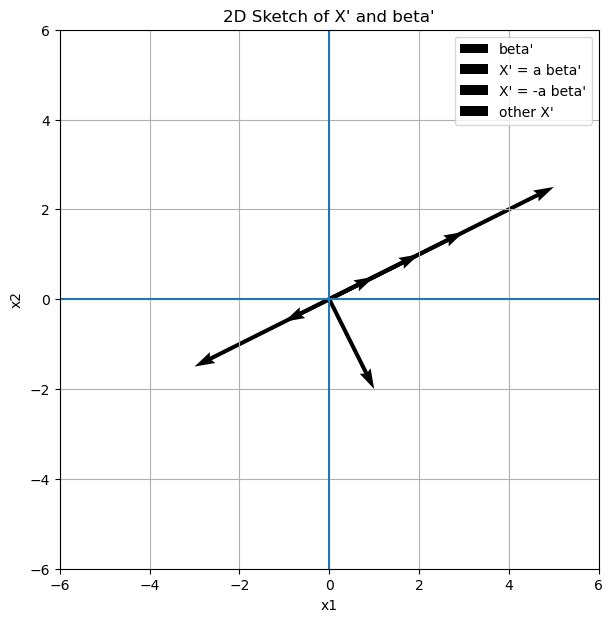

In [6]:
import numpy as np
import matplotlib.pyplot as plt
import os

os.makedirs("plots", exist_ok=True)

# Fixed beta' vector
beta = np.array([2, 1])

# Example X' vectors
x_max1 = 0.5 * beta
x_max2 = 1.5 * beta
x_max3 = 2.5 * beta
x_min1 = -0.5 * beta
x_min2 = -1.5 * beta
x_other = np.array([1, -2])

plt.figure(figsize=(7, 7))

# Draw beta'
plt.quiver(0, 0, beta[0], beta[1], angles='xy', scale_units='xy', scale=1, label="beta'")

# Draw X' vectors that maximize the probability
plt.quiver(0, 0, x_max1[0], x_max1[1], angles='xy', scale_units='xy', scale=1, label="X' = a beta'")
plt.quiver(0, 0, x_max2[0], x_max2[1], angles='xy', scale_units='xy', scale=1)
plt.quiver(0, 0, x_max3[0], x_max3[1], angles='xy', scale_units='xy', scale=1)

# Draw X' vectors that minimize the probability
plt.quiver(0, 0, x_min1[0], x_min1[1], angles='xy', scale_units='xy', scale=1, label="X' = -a beta'")
plt.quiver(0, 0, x_min2[0], x_min2[1], angles='xy', scale_units='xy', scale=1)

# Draw another example vector
plt.quiver(0, 0, x_other[0], x_other[1], angles='xy', scale_units='xy', scale=1, label="other X'")

plt.xlim(-6, 6)
plt.ylim(-6, 6)
plt.axhline(0)
plt.axvline(0)
plt.grid(True)
plt.gca().set_aspect('equal', adjustable='box')
plt.title("2D Sketch of X' and beta'")
plt.xlabel("x1")
plt.ylabel("x2")
plt.legend()

plt.savefig("plots/problem2c_sketch.png", dpi=300, bbox_inches="tight")
plt.show()

2cii

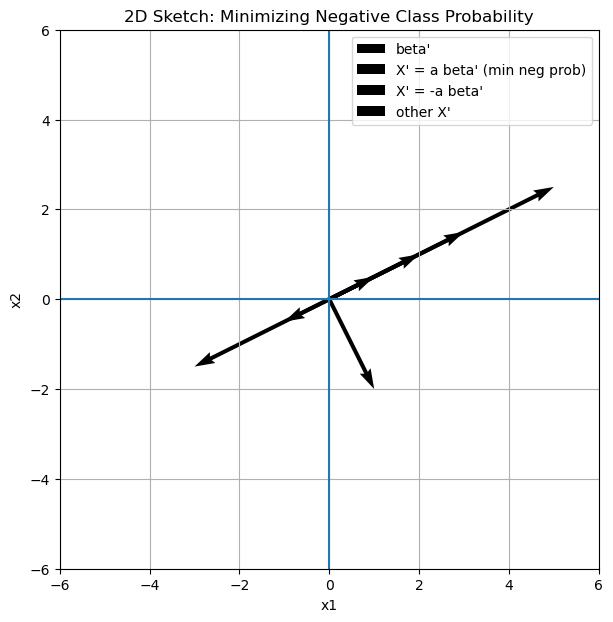

In [7]:
import numpy as np
import matplotlib.pyplot as plt
import os

os.makedirs("plots", exist_ok=True)

# Fixed beta' vector
beta = np.array([2, 1])

# X' that maximize z (→ minimize negative probability)
x_pos1 = 0.5 * beta
x_pos2 = 1.5 * beta
x_pos3 = 2.5 * beta

# X' that minimize z (opposite direction)
x_neg1 = -0.5 * beta
x_neg2 = -1.5 * beta

# Other example
x_other = np.array([1, -2])

plt.figure(figsize=(7, 7))

# beta'
plt.quiver(0, 0, beta[0], beta[1], angles='xy', scale_units='xy', scale=1, label="beta'")

# Same direction (maximize z → minimize negative prob)
plt.quiver(0, 0, x_pos1[0], x_pos1[1], angles='xy', scale_units='xy', scale=1,
           label="X' = a beta' (min neg prob)")
plt.quiver(0, 0, x_pos2[0], x_pos2[1], angles='xy', scale_units='xy', scale=1)
plt.quiver(0, 0, x_pos3[0], x_pos3[1], angles='xy', scale_units='xy', scale=1)

# Opposite direction (minimize z → maximize negative prob)
plt.quiver(0, 0, x_neg1[0], x_neg1[1], angles='xy', scale_units='xy', scale=1,
           label="X' = -a beta'")
plt.quiver(0, 0, x_neg2[0], x_neg2[1], angles='xy', scale_units='xy', scale=1)

# Other vector
plt.quiver(0, 0, x_other[0], x_other[1], angles='xy', scale_units='xy', scale=1,
           label="other X'")

plt.xlim(-6, 6)
plt.ylim(-6, 6)
plt.axhline(0)
plt.axvline(0)
plt.grid(True)
plt.gca().set_aspect('equal', adjustable='box')
plt.title("2D Sketch: Minimizing Negative Class Probability")
plt.xlabel("x1")
plt.ylabel("x2")
plt.legend()

plt.savefig("plots/problem2c_negative.png", dpi=300, bbox_inches="tight")
plt.show()

2ciii

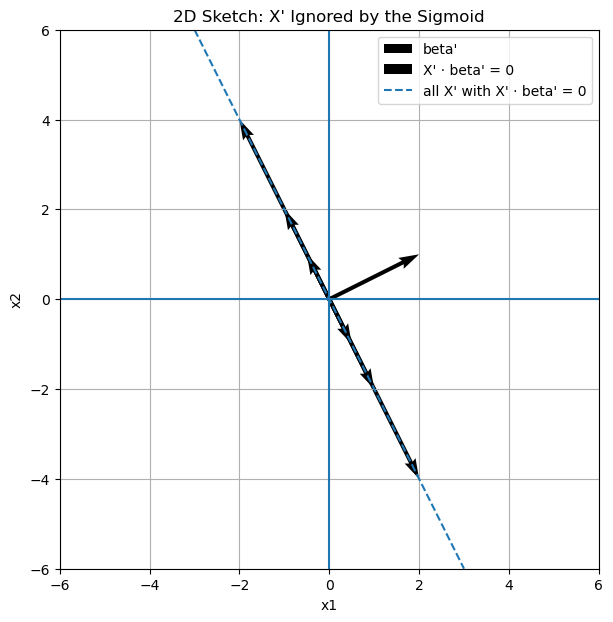

In [8]:
import numpy as np
import matplotlib.pyplot as plt
import os

os.makedirs("plots", exist_ok=True)

# Fixed beta' vector
beta = np.array([2, 1])

# A direction perpendicular to beta' = [2,1] is [1,-2],
# since [2,1] dot [1,-2] = 2*1 + 1*(-2) = 0
perp = np.array([1, -2])

# Example X' vectors that satisfy X' dot beta' = 0
x_ignored1 = 0.5 * perp
x_ignored2 = 1.0 * perp
x_ignored3 = 2.0 * perp
x_ignored4 = -0.5 * perp
x_ignored5 = -1.0 * perp
x_ignored6 = -2.0 * perp

plt.figure(figsize=(7, 7))

# Plot beta'
plt.quiver(0, 0, beta[0], beta[1], angles='xy', scale_units='xy', scale=1, label="beta'")

# Plot ignored X' vectors (perpendicular to beta')
plt.quiver(0, 0, x_ignored1[0], x_ignored1[1], angles='xy', scale_units='xy', scale=1,
           label="X' · beta' = 0")
plt.quiver(0, 0, x_ignored2[0], x_ignored2[1], angles='xy', scale_units='xy', scale=1)
plt.quiver(0, 0, x_ignored3[0], x_ignored3[1], angles='xy', scale_units='xy', scale=1)
plt.quiver(0, 0, x_ignored4[0], x_ignored4[1], angles='xy', scale_units='xy', scale=1)
plt.quiver(0, 0, x_ignored5[0], x_ignored5[1], angles='xy', scale_units='xy', scale=1)
plt.quiver(0, 0, x_ignored6[0], x_ignored6[1], angles='xy', scale_units='xy', scale=1)

# Draw the line of all ignored X' values
t = np.linspace(-3, 3, 100)
line_x = t * perp[0]
line_y = t * perp[1]
plt.plot(line_x, line_y, linestyle='--', label="all X' with X' · beta' = 0")

plt.xlim(-6, 6)
plt.ylim(-6, 6)
plt.axhline(0)
plt.axvline(0)
plt.grid(True)
plt.gca().set_aspect('equal', adjustable='box')
plt.title("2D Sketch: X' Ignored by the Sigmoid")
plt.xlabel("x1")
plt.ylabel("x2")
plt.legend()

plt.savefig("plots/problem2c_ignored.png", dpi=300, bbox_inches="tight")
plt.show()

2di

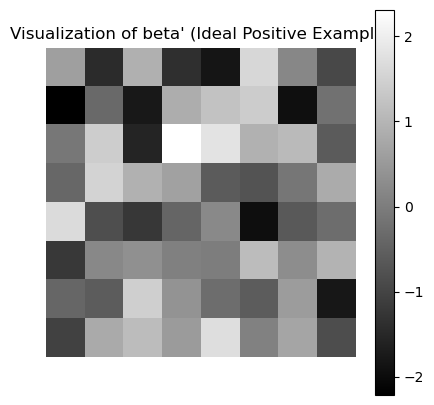

In [9]:
import numpy as np
import matplotlib.pyplot as plt
import os

os.makedirs("plots", exist_ok=True)

# Example beta' (pretend it's learned weights)
# Here we create a fake "image-like" beta'
beta = np.random.randn(64)  # 8x8 image

# Reshape into image
beta_img = beta.reshape(8, 8)

plt.figure(figsize=(5,5))
plt.imshow(beta_img, cmap='gray')
plt.colorbar()
plt.title("Visualization of beta' (Ideal Positive Example)")
plt.axis('off')

plt.savefig("plots/problem2d_beta_visualization.png", dpi=300, bbox_inches="tight")
plt.show()

2dii

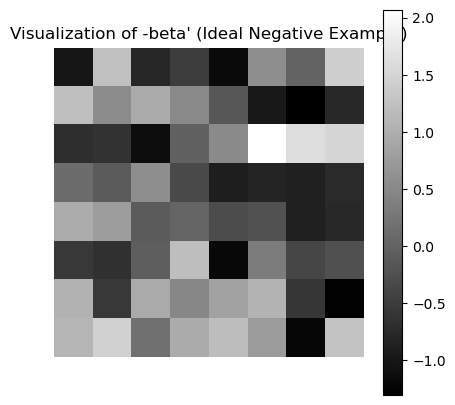

In [10]:
import numpy as np
import matplotlib.pyplot as plt
import os

os.makedirs("plots", exist_ok=True)

# Same beta' as before (example)
beta = np.random.randn(64)  # 8x8 image

# Ideal negative example = -beta'
beta_neg = -beta
beta_neg_img = beta_neg.reshape(8, 8)

plt.figure(figsize=(5,5))
plt.imshow(beta_neg_img, cmap='gray')
plt.colorbar()
plt.title("Visualization of -beta' (Ideal Negative Example)")
plt.axis('off')

plt.savefig("plots/problem2d_beta_negative.png", dpi=300, bbox_inches="tight")
plt.show()

3e

In [ ]:
from transformers import GPT2Tokenizer, GPT2LMHeadModel

gpt2_tokenizer = GPT2Tokenizer.from_pretrained("gpt2")
gpt2 = GPT2LMHeadModel.from_pretrained("gpt2")

prompt = "Once upon a time"

tokenized_prompt = gpt2_tokenizer(prompt, return_tensors="pt")

for i in range(10):
    output = gpt2.generate(
        **tokenized_prompt,
        max_length=50,
        do_sample=True,      # MUST be True
        top_p=0.1            # nucleus sampling
    )

    print(f"{i + 1}) {gpt2_tokenizer.batch_decode(output)[0]}")

ModuleNotFoundError: No module named 'transformers'

3f

In [ ]:
from transformers import GPT2Tokenizer, GPT2LMHeadModel

gpt2_tokenizer = GPT2Tokenizer.from_pretrained("gpt2")
gpt2 = GPT2LMHeadModel.from_pretrained("gpt2")

prompt = "Once upon a time"

tokenized_prompt = gpt2_tokenizer(prompt, return_tensors="pt")

for i in range(10):
    output = gpt2.generate(
        **tokenized_prompt,
        max_length=50,
        do_sample=True,      # MUST be True
        top_p=0.1            # nucleus sampling
    )

    print(f"{i + 1}) {gpt2_tokenizer.batch_decode(output)[0]}")

3g

In [ ]:
from transformers import GPT2Tokenizer, GPT2LMHeadModel

gpt2_tokenizer = GPT2Tokenizer.from_pretrained("gpt2")
gpt2 = GPT2LMHeadModel.from_pretrained("gpt2")

prompt = "Once upon a time"

tokenized_prompt = gpt2_tokenizer(prompt, return_tensors="pt")

for i in range(10):
    output = gpt2.generate(
        **tokenized_prompt,
        max_length=50,
        do_sample=True,   # must be True for top_p to work
        top_p=0.99
    )

    print(f"{i + 1}) {gpt2_tokenizer.batch_decode(output)[0]}")